## import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

In [2]:
import pandas as pd
import re

gff_path = '/gale/raidix/rdx-7/jwalker/Kay_Qu/c1038_genes_overlapping_c2952_dmw_chunks.gff'

# 1. Read the GFF (Skipping comment lines starting with '#')
# GFFs are tab-separated and have 9 standard columns
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
df_gff = pd.read_csv(gff_path, sep='\t', comment='#', header=None, names=gff_cols)

# 2. Filter for 'gene' features only (Column 3)
genes_only = df_gff[df_gff['type'] == 'gene'].copy()

# 3. Extract the ID from the 'attributes' column
# Usually looks like: "ID=gene:AT1G01010;Name=..." or "ID=AT1G01010"
def extract_id(attr_string):
    # This regex looks for 'ID=' followed by characters until a semicolon or end of string
    match = re.search(r'ID=([^;]+)', attr_string)
    if match:
        gene_id = match.group(1)
        # Clean up common prefixes like 'gene:' if they exist
        return gene_id.replace('gene:', '')
    return None

# Apply the extraction
new_gene_list = genes_only['attributes'].apply(extract_id).dropna().unique().tolist()

# 4. Update your pipeline variable
hazel_genes = pd.Index(new_gene_list)

print(f"✅ Loaded {len(hazel_genes)} unique Gene IDs from the GFF file.")
print(f"Sample IDs: {new_gene_list[:5]}")

✅ Loaded 1038 unique Gene IDs from the GFF file.
Sample IDs: ['AT1G01300', 'AT1G01770', 'AT1G01780', 'AT1G01830', 'AT1G01950']


# cluster_rna_matrix

In [3]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


# filtered_meth_df

In [14]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# # Mask genes with extremely low total coverage to avoid noise
# valid_genes_mask = gene_m >= 50 
# cluster_c = cluster_c[valid_genes_mask]
# cluster_m = cluster_m[valid_genes_mask]
# gene_c = gene_c[valid_genes_mask]
# gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.0).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (32833, 17)


In [15]:
import statsmodels.api as sm
from scipy.stats import zscore

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index).intersection(hazel_genes)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho       p_value       fdr
gene                                       
AT1G52240 -1.302113  1.152109e-03  0.013853
AT3G21670 -1.298125  2.691938e-05  0.000948
AT3G26290 -1.294671  5.557122e-06  0.000352
AT5G49740 -1.251251  1.788352e-05  0.000767
AT4G04330 -1.238686  1.420823e-02  0.086773
AT5G57760 -1.196886  5.778649e-04  0.008633
AT2G34430 -1.180831  8.773747e-07  0.000093
AT1G47530 -1.171670  6.872320e-03  0.050568
AT1G71140 -1.167343  6.304911e-06  0.000366
AT5G38430 -1.163807  2.693313e-05  0.000948
AT4G12310 -1.156196  1.739895e-02  0.100324
AT4G14100 -1.148804  3.315699e-02  0.152019
AT5G09660 -1.135077  6.878395e-05  0.002119
AT4G17090 -1.121434  1.595487e-03  0.018082
AT1G29910 -1.118254  7.261109e-05  0.002170
AT4G26150 -1.106202  8.211550e-04  0.010795
AT2G01918 -1.102897  1.264681e-02  0.080705
AT2G01590 -1.096522  9.876716e-03  0.066236
AT1G23480 -1.093320  2.078998e-04  0.004470
AT3G54890 -1.09

In [16]:
final_meth_df

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
AT1G01300,0.000650,-0.000613,-0.000063,0.000707,-0.001403,-0.001344,-0.001317,-0.001546,0.004148,0.001335,0.000863,-0.000132,-0.002628,-0.003783,0.001008,0.008387,0.004041
AT1G01770,-0.004478,0.013709,-0.009721,0.019368,-0.004131,0.004853,-0.027943,0.004450,-0.031873,0.016932,-0.026545,0.046778,0.005897,-0.029838,0.062445,0.014019,0.061360
AT1G01780,0.000349,-0.001982,0.000073,-0.000270,0.001817,0.005754,-0.002770,0.000384,0.000815,-0.001868,-0.000831,-0.002007,0.001854,-0.003565,-0.002689,0.011865,0.002186
AT1G01830,0.000648,-0.001471,0.000243,0.000225,-0.000761,-0.000184,0.000579,-0.002601,0.000372,0.003448,0.002554,-0.000159,-0.003134,0.000413,0.001031,0.000816,0.007053
AT1G01950,0.000625,0.003541,0.005192,-0.022578,0.000061,0.000194,-0.000771,0.011628,-0.016371,-0.003327,-0.011984,0.009813,-0.047038,0.016334,0.005652,0.013353,-0.010393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G66520,-0.030017,-0.013393,0.020644,-0.047430,0.036417,0.109253,0.049791,0.014366,-0.021710,0.014268,-0.063079,0.021071,-0.028012,0.078643,0.030304,0.137333,0.026317
AT5G66600,-0.005526,0.020831,-0.017426,-0.002562,0.001077,-0.005517,-0.003742,-0.007793,-0.015662,0.014505,-0.005153,0.033423,0.000785,-0.002759,-0.020728,0.049709,-0.062669
AT5G67340,-0.019499,0.006505,-0.012269,-0.023657,0.036686,0.037265,0.024696,0.003676,0.012851,-0.038370,-0.000605,-0.037012,-0.026863,0.019000,0.033934,0.036086,-0.050852
AT5G67385,0.013075,0.012862,0.022910,-0.011427,-0.030058,0.040691,-0.043035,-0.027759,-0.052370,0.060711,-0.033731,0.040758,0.018606,-0.042623,-0.054937,0.092629,0.047470


In [17]:
def identify_relative_lows(gene_list, obs_p, adj_meth_matrix, cluster_m, 
                           min_coverage=10, 
                           residual_threshold=-0.05,    # RELAXED: Only require a 5% drop
                           zscore_threshold=-1.0,       # RELAXED: Only 1 standard dev below mean
                           min_raw_max=0.05):           # RELAXED: Gene only needs 5% max methylation
    results = []
    valid_genes = [g for g in gene_list if g in adj_meth_matrix.index]
    
    for gene in valid_genes:
        gene_obs = obs_p.loc[gene]
        gene_adj = adj_meth_matrix.loc[gene]
        gene_cov = cluster_m.loc[gene]
        
        # Relaxed global unmethylated check
        if gene_obs.max() < min_raw_max:
            continue
            
        valid_clusters_mask = gene_cov >= min_coverage
        if valid_clusters_mask.sum() < 3:
            continue 
            
        valid_adj = gene_adj[valid_clusters_mask]
        adj_zscores = pd.Series(zscore(valid_adj), index=valid_adj.index)
        
        # Apply relaxed thresholds
        hypo_clusters = valid_adj[(valid_adj <= residual_threshold) & (adj_zscores <= zscore_threshold)].index.tolist()
        
        if hypo_clusters:
            for cluster in hypo_clusters:
                results.append({
                    'Gene': gene,
                    'Cluster': cluster,
                    'Raw_Fraction': gene_obs[cluster],
                    'Residual': valid_adj[cluster],
                    'Z_Score': adj_zscores[cluster],
                    'Coverage': gene_cov[cluster]
                })
                
    if not results:
        return pd.DataFrame()
    return pd.DataFrame(results).sort_values(by=['Gene', 'Residual'])

# --- Run with Relaxed Parameters for AT4G30400 ---
relaxed_results = identify_relative_lows(
    gene_list=['AT4G30400'],
    obs_p=obs_p, 
    adj_meth_matrix=adj_meth_matrix, 
    cluster_m=cluster_m,
    residual_threshold=-0.03,  # Just a 3% absolute drop required
    zscore_threshold=-1.0,     # 1 standard deviation below its own mean
    min_raw_max=0.00           # Turn off the "must be methylated somewhere" filter completely
)

display(relaxed_results)

,Gene,Cluster,Raw_Fraction,Residual,Z_Score,Coverage
1,AT4G30400,6.0,0.060750,-0.097046,-1.705512,2535
3,AT4G30400,14.0,0.107362,-0.071955,-1.229108,326
0,AT4G30400,4.0,0.100870,-0.067541,-1.145306,3906
2,AT4G30400,13.0,0.096386,-0.067230,-1.139404,830


In [21]:
import pandas as pd

# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# 1. Run the function on all aligned genes to capture all hypomethylation events
all_hypo_results = identify_relative_lows(
    gene_list=common_genes,       # Using all genes present in both modalities
    obs_p=obs_p, 
    adj_meth_matrix=adj_meth_matrix, 
    cluster_m=cluster_m,
    residual_threshold=-0.02,     # Adjust these thresholds if you want them stricter/looser
    zscore_threshold=-0.5,     
    min_raw_max=0.02           
)

# 2. Group the results by cluster and extract the gene names
cluster_gene_dict = {}
for cluster_id, group in all_hypo_results.groupby('Cluster'):
    # Map the numeric cluster ID to your descriptive string name
    cluster_name = cluster_mapping.get(cluster_id, str(cluster_id))
    # Extract the unique genes for this cluster
    cluster_gene_dict[cluster_name] = group['Gene'].unique().tolist()

# 3. Assemble into a DataFrame, padding uneven columns with NaNs
hypo_genes_by_cluster_df = pd.DataFrame({
    cluster: pd.Series(genes) 
    for cluster, genes in cluster_gene_dict.items()
})

# 4. Optional: Reorder the columns to match your preferred biological order
valid_cols = [c for c in cluster_order if c in hypo_genes_by_cluster_df.columns]
hypo_genes_by_cluster_df = hypo_genes_by_cluster_df[valid_cols]

# Display the resulting table
display(hypo_genes_by_cluster_df.head(10))

# To save this table to a CSV for external use:
hypo_genes_by_cluster_df.to_csv("./data/hypomethylated_genes_by_cluster_filtered_c1038.csv", index=False)

,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
0,AT1G01950,AT1G07380,AT1G07520,AT1G07520,AT1G01770,AT1G11410,AT1G01770,AT1G02110,AT1G01770,AT1G01770,AT1G02500,AT1G09460,AT1G03300,AT1G07990,AT1G08680,AT1G01950,AT1G04030
1,AT1G08460,AT1G11860,AT1G14280,AT1G09160,AT1G02500,AT1G14560,AT1G02110,AT1G04030,AT1G02110,AT1G02110,AT1G05620,AT1G17150,AT1G09460,AT1G09460,AT1G08940,AT1G07990,AT1G14530
2,AT1G08680,AT1G14710,AT1G14710,AT1G11860,AT1G07990,AT1G17920,AT1G02500,AT1G05620,AT1G02500,AT1G03290,AT1G08460,AT1G24100,AT1G14530,AT1G17150,AT1G09460,AT1G08680,AT1G14710
3,AT1G20400,AT1G20470,AT1G14770,AT1G20470,AT1G08680,AT1G26762,AT1G05620,AT1G08940,AT1G03290,AT1G03300,AT1G08940,AT1G31500,AT1G15750,AT1G18050,AT1G11300,AT1G09460,AT1G17070
4,AT1G20980,AT1G29910,AT1G17150,AT1G29620,AT1G08840,AT1G30600,AT1G07650,AT1G11300,AT1G04030,AT1G04030,AT1G14280,AT1G32520,AT1G19090,AT1G19090,AT1G15165,AT1G11960,AT1G18050
5,AT1G26762,AT1G32010,AT1G18550,AT1G29910,AT1G11410,AT1G34790,AT1G08190,AT1G11350,AT1G05620,AT1G05620,AT1G14560,AT1G49230,AT1G21060,AT1G20400,AT1G17070,AT1G14770,AT1G20980
6,AT1G29910,AT1G34042,AT1G18660,AT1G30540,AT1G14530,AT1G42550,AT1G08940,AT1G11410,AT1G08840,AT1G07990,AT1G17150,AT1G50055,AT1G24100,AT1G25280,AT1G17150,AT1G17070,AT1G25280
7,AT1G33680,AT1G37113,AT1G26380,AT1G32520,AT1G15750,AT1G47280,AT1G10850,AT1G14530,AT1G11300,AT1G08190,AT1G18050,AT1G53680,AT1G25280,AT1G26390,AT1G19090,AT1G19090,AT1G26390
8,AT1G34042,AT1G47578,AT1G26940,AT1G35240,AT1G17450,AT1G52905,AT1G11300,AT1G14560,AT1G11310,AT1G08680,AT1G19370,AT1G60800,AT1G26410,AT1G29620,AT1G24100,AT1G29620,AT1G26410
9,AT1G35515,AT1G47580,AT1G29440,AT1G37113,AT1G18050,AT1G53680,AT1G11310,AT1G17920,AT1G11350,AT1G08840,AT1G20470,AT1G62560,AT1G30360,AT1G32010,AT1G27960,AT1G35240,AT1G26940


In [22]:
hypo_genes_by_cluster_df

,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
0,AT1G01950,AT1G07380,AT1G07520,AT1G07520,AT1G01770,AT1G11410,AT1G01770,AT1G02110,AT1G01770,AT1G01770,AT1G02500,AT1G09460,AT1G03300,AT1G07990,AT1G08680,AT1G01950,AT1G04030
1,AT1G08460,AT1G11860,AT1G14280,AT1G09160,AT1G02500,AT1G14560,AT1G02110,AT1G04030,AT1G02110,AT1G02110,AT1G05620,AT1G17150,AT1G09460,AT1G09460,AT1G08940,AT1G07990,AT1G14530
2,AT1G08680,AT1G14710,AT1G14710,AT1G11860,AT1G07990,AT1G17920,AT1G02500,AT1G05620,AT1G02500,AT1G03290,AT1G08460,AT1G24100,AT1G14530,AT1G17150,AT1G09460,AT1G08680,AT1G14710
3,AT1G20400,AT1G20470,AT1G14770,AT1G20470,AT1G08680,AT1G26762,AT1G05620,AT1G08940,AT1G03290,AT1G03300,AT1G08940,AT1G31500,AT1G15750,AT1G18050,AT1G11300,AT1G09460,AT1G17070
4,AT1G20980,AT1G29910,AT1G17150,AT1G29620,AT1G08840,AT1G30600,AT1G07650,AT1G11300,AT1G04030,AT1G04030,AT1G14280,AT1G32520,AT1G19090,AT1G19090,AT1G15165,AT1G11960,AT1G18050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AT5G63010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AT5G63020,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AT5G64740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AT5G66520,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Hypomethylation Summary ---
Total unique hypomethylated genes: 873

Number of hypomethylated genes per cluster:
3 Early M          58
0 Mid M            52
7 Expanding M     147
1 Late M          143
10 Senescent M    284
5 Early E          77
13 Expanding E    278
4 Abaxial E       219
6 Adaxial E       304
8 Senescent E     367
14 Guard cell     246
2 Vasculature      47
11 PPP            139
9 Phloem          200
16 Myrosinase     218
12 S phase        132
15 G2M phase      173

Distribution of events per gene:
Clusters : Number of Genes
count
1    117
2    130
3    163
4    216
5    155
6     70
7     17
8      5


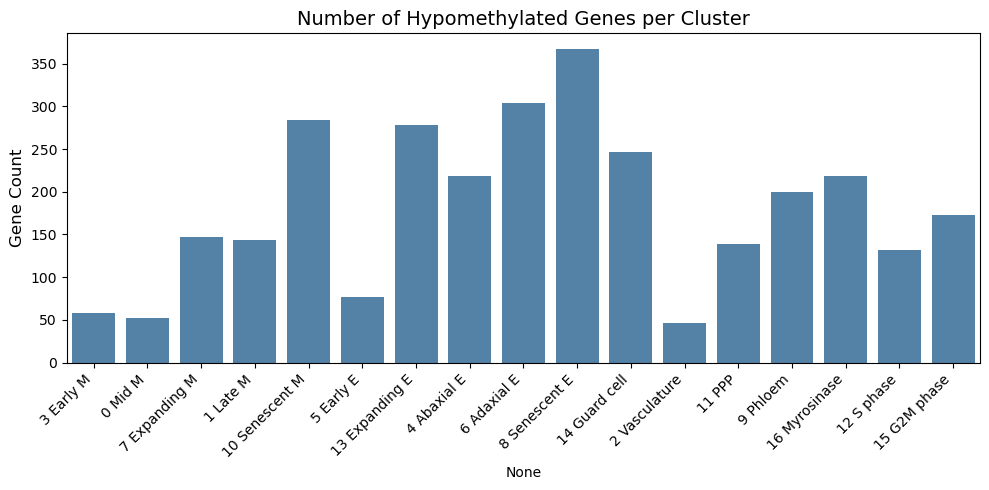

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Hypomethylation Summary ---")

# 1. Total unique genes flagged across all clusters
total_unique = len(all_hypo_results['Gene'].unique())
print(f"Total unique hypomethylated genes: {total_unique}")

# 2. Number of hypomethylated genes per cluster
# The .count() method automatically ignores NaN values
genes_per_cluster = hypo_genes_by_cluster_df.count()
print("\nNumber of hypomethylated genes per cluster:")
print(genes_per_cluster.to_string())

# 3. How many clusters is a single gene hypomethylated in?
# This counts how often each gene appears in the master list
cluster_counts_per_gene = all_hypo_results['Gene'].value_counts()
print("\nDistribution of events per gene:")
print("Clusters : Number of Genes")
print(cluster_counts_per_gene.value_counts().sort_index().to_string())

# --- Quick Visualization ---
plt.figure(figsize=(10, 5))
sns.barplot(x=genes_per_cluster.index, y=genes_per_cluster.values, color='steelblue')
plt.title("Number of Hypomethylated Genes per Cluster", fontsize=14)
plt.ylabel("Gene Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()